In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Aqui pongan la ruta dentro de su computadora a el archivo .hdf5
PATH = "/content/drive/MyDrive/galaxiesML/DESI_HSC_64x64_v2.hdf5"


f = h5py.File(PATH, "r")

wave = f["spectrum/wave"][:]
flux = f["spectrum/flux"][:]
images = f['image'][:]
redshifts = f['DESI_fibermap/DESI_redshift'][:]
num_missing_pixels= f['DESI_fibermap/num_missing_pixels'][:]

f.close()


In [10]:

f = h5py.File(PATH, "r")
wave = f["spectrum/wave"][:]
flux = f["spectrum/flux"][:]
f.close()

Resumen de la base de datos

In [11]:
print("===== SHAPES =====")
print("images:", images.shape)
print("flux:", flux.shape)
print("redshifts:", redshifts.shape)
print("num_missing_pixels:", num_missing_pixels.shape)

print("\n===== DTYPES =====")
print("images:", images.dtype)
print("flux:", flux.dtype)
print("redshifts:", redshifts.dtype)
print("num_missing_pixels:", num_missing_pixels.dtype)

print("\n===== MEMORIA =====")
print(f"images: {images.nbytes / 1e9:.2f} GB")
print(f"flux: {flux.nbytes / 1e9:.2f} GB")

===== SHAPES =====
images: (134533, 5, 64, 64)
flux: (134533, 7783)
redshifts: (134533,)
num_missing_pixels: (134533,)

===== DTYPES =====
images: float32
flux: float64
redshifts: float64
num_missing_pixels: int64

===== MEMORIA =====
images: 11.02 GB
flux: 8.38 GB


Estadísticas generales de las imágenes

In [12]:
print("===== IMAGES =====")

print("min:", np.nanmin(images))
print("max:", np.nanmax(images))
print("mean:", np.nanmean(images))
print("std:", np.nanstd(images))

print("\nPercentiles:")
for p in [0, 1, 5, 25, 50, 75, 95, 99, 100]:
    print(f"{p:>3}%:", np.nanpercentile(images, p))

===== IMAGES =====
min: -633.2002
max: 1688.4653
mean: 0.8718003
std: 3.5857403

Percentiles:
  0%: -633.2002
  1%: -0.33661392
  5%: -0.10117397
 25%: 0.022359814
 50%: 0.1362406
 75%: 0.5325883
 95%: 3.6841524
 99%: 12.816973
100%: 1688.4653


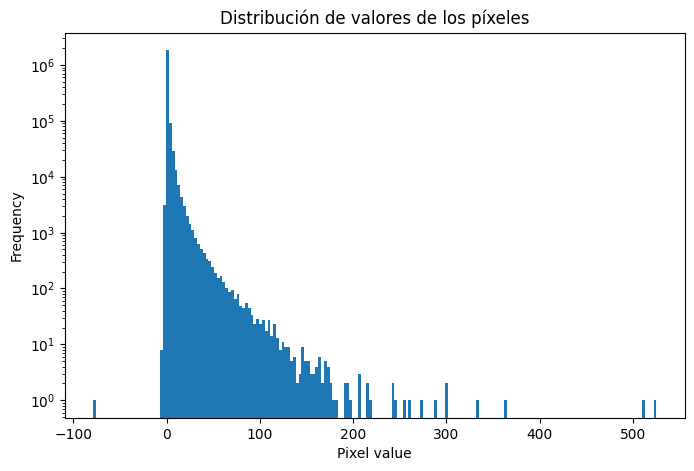

In [13]:
plt.figure(figsize=(8,5))

sample = images.ravel()

# Para evitar que una cantidad enorme de datos haga lento el histograma
if len(sample) > 2_000_000:
    sample = np.random.choice(sample, 2_000_000, replace=False)

plt.hist(sample, bins=200)
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.title("Distribución de valores de los píxeles")
plt.yscale("log")
plt.show()

Visualizar galaxias

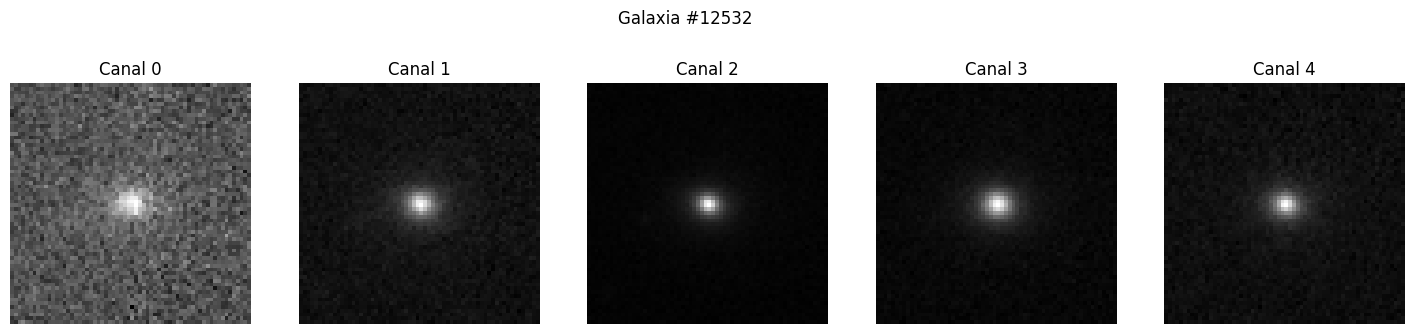

In [14]:
idx = np.random.randint(len(images))

fig, axes = plt.subplots(1, 5, figsize=(18,4))

for i in range(5):
    axes[i].imshow(images[idx, i], cmap="gray")
    axes[i].set_title(f"Canal {i}")
    axes[i].axis("off")

plt.suptitle(f"Galaxia #{idx}")
plt.show()

Missing pixels

In [15]:
print("===== MISSING PIXELS =====")

print("Total de galaxias:", len(num_missing_pixels))
print("Galaxias con missing pixels:",
      np.sum(num_missing_pixels > 0))

print("Porcentaje:",
      100 * np.mean(num_missing_pixels > 0), "%")

print("Máximo:", np.max(num_missing_pixels))
print("Media:", np.mean(num_missing_pixels))
print("Mediana:", np.median(num_missing_pixels))

===== MISSING PIXELS =====
Total de galaxias: 134533
Galaxias con missing pixels: 134533
Porcentaje: 100.0 %
Máximo: 2811
Media: 34.809860777653064
Mediana: 26.0


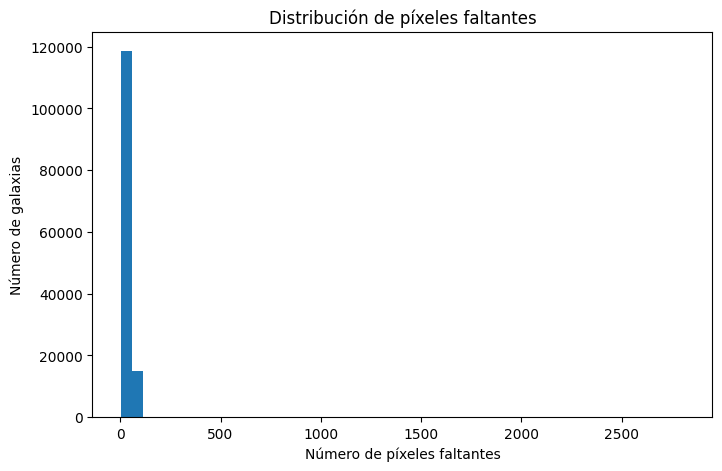

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    num_missing_pixels,
    bins=50
)

plt.xlabel("Número de píxeles faltantes")
plt.ylabel("Número de galaxias")
plt.title("Distribución de píxeles faltantes")
plt.show()

Nan e infinitos

In [17]:
def missing_report(name, x):
    print(f"\n===== {name} =====")
    print("NaN:", np.isnan(x).sum())
    print("Inf:", np.isinf(x).sum())
    print("Total:", x.size)
    print("Porcentaje:",
          100 * (np.isnan(x).sum() + np.isinf(x).sum()) / x.size)

missing_report("images", images)
missing_report("flux", flux)
missing_report("redshifts", redshifts)
missing_report("num_missing_pixels", num_missing_pixels)


===== images =====
NaN: 0
Inf: 0
Total: 2755235840
Porcentaje: 0.0

===== flux =====
NaN: 0
Inf: 0
Total: 1047070339
Porcentaje: 0.0

===== redshifts =====
NaN: 0
Inf: 0
Total: 134533
Porcentaje: 0.0

===== num_missing_pixels =====
NaN: 0
Inf: 0
Total: 134533
Porcentaje: 0.0


Redshift

In [18]:
print("===== REDSHIFT =====")

print("N:", len(redshifts))
print("Min:", np.nanmin(redshifts))
print("Max:", np.nanmax(redshifts))
print("Mean:", np.nanmean(redshifts))
print("Median:", np.nanmedian(redshifts))
print("Std:", np.nanstd(redshifts))

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p}:", np.nanpercentile(redshifts, p))

===== REDSHIFT =====
N: 134533
Min: -0.0007584043058847
Max: 4.119430389565667
Mean: 0.5718946051273618
Median: 0.3313414791205642
Std: 0.6755563107422228
P1: 0.038123774232426084
P5: 0.07597141886733415
P25: 0.162727596534247
P50: 0.3313414791205642
P75: 0.6051626199663013
P95: 2.3156201660052647
P99: 3.043342718420674


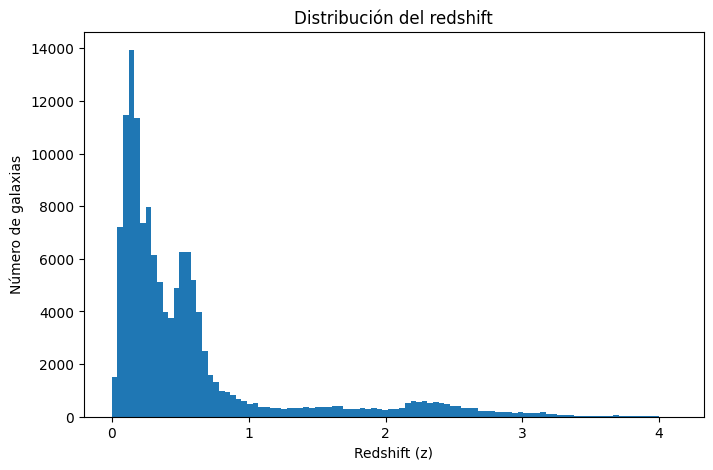

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    redshifts,
    bins=100
)

plt.xlabel("Redshift (z)")
plt.ylabel("Número de galaxias")
plt.title("Distribución del redshift")
plt.show()

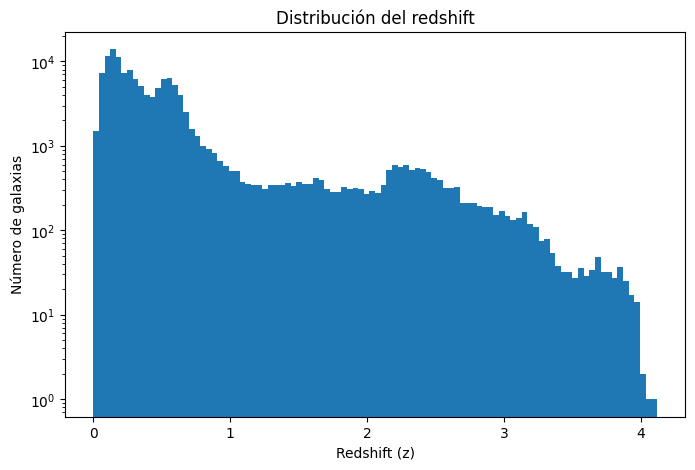

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    redshifts,
    bins=100
)

plt.xlabel("Redshift (z)")
plt.ylabel("Número de galaxias")
plt.yscale("log")
plt.title("Distribución del redshift")
plt.show()

imagen-redshift

In [21]:
bins = np.quantile(
    redshifts,
    [0, .2, .4, .6, .8, 1]
)

groups = np.digitize(redshifts, bins[1:-1])

for g in range(5):

    idx = np.where(groups == g)[0]

    print(
        f"Grupo {g+1}: "
        f"N={len(idx)}, "
        f"z median={np.median(redshifts[idx]):.4f}"
    )

Grupo 1: N=26907, z median=0.0995
Grupo 2: N=26906, z median=0.1859
Grupo 3: N=26907, z median=0.3313
Grupo 4: N=26906, z median=0.5562
Grupo 5: N=26907, z median=1.5809


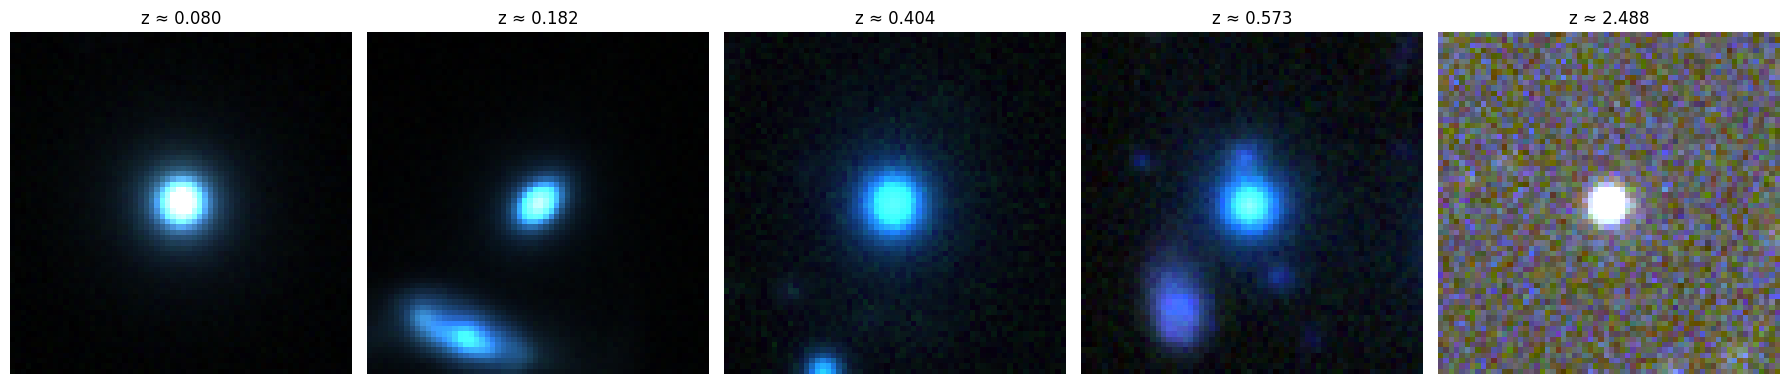

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(18,4))

for g in range(5):

    idx = np.where(groups == g)[0]
    example = np.random.choice(idx)

    img = images[example, :3].transpose(1,2,0)

    lo, hi = np.percentile(img, [1,99])
    img = np.clip((img-lo)/(hi-lo), 0, 1)

    axes[g].imshow(img)
    axes[g].set_title(
        f"z ≈ {redshifts[example]:.3f}"
    )
    axes[g].axis("off")

plt.tight_layout()
plt.show()

Espectros

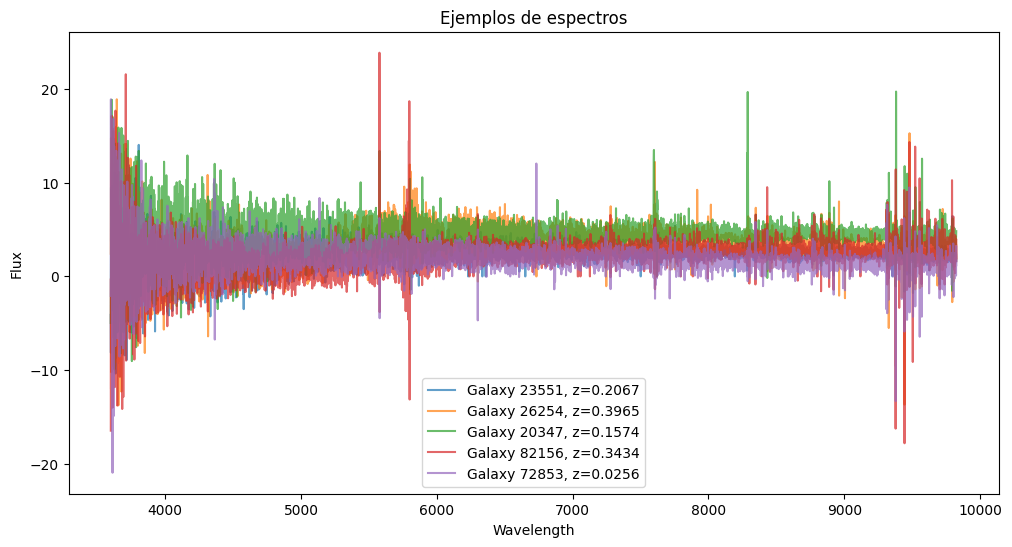

In [25]:
indices = np.random.choice(
    len(flux),
    size=5,
    replace=False
)

plt.figure(figsize=(12, 6))

for idx in indices:

    plt.plot(
        wave[idx],
        flux[idx],
        alpha=0.7,
        label=f"Galaxy {idx}, z={redshifts[idx]:.4f}"
    )

plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.title("Ejemplos de espectros")
plt.legend()

plt.show()

In [26]:
spectral_mean = np.nanmean(flux, axis=1)
spectral_std = np.nanstd(flux, axis=1)
spectral_min = np.nanmin(flux, axis=1)
spectral_max = np.nanmax(flux, axis=1)

print("===== SPECTRAL STATISTICS =====")

for name, x in [
    ("Mean flux", spectral_mean),
    ("Std flux", spectral_std),
    ("Min flux", spectral_min),
    ("Max flux", spectral_max)
]:
    print(f"\n{name}")
    print("mean:", np.mean(x))
    print("median:", np.median(x))
    print("std:", np.std(x))

===== SPECTRAL STATISTICS =====

Mean flux
mean: 3.366222093523197
median: 2.2815597711684727
std: 3.3777601633607377

Std flux
mean: 1.7801888671407267
median: 1.564343278187158
std: 1.28929019109211

Min flux
mean: -13.758755462673872
median: -11.510782241821289
std: 10.348682142464131

Max flux
mean: 25.453101481104923
median: 17.9606876373291
std: 44.38632365091771
